In [1]:
import pandas as pd
df=pd.read_csv("Nassau Candy Distributor.csv")

In [2]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [3]:
df["Lead Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [4]:
df["Lead Time"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

In [5]:
df.dropna(inplace=True)

In [6]:
df.drop_duplicates(inplace=True)

In [8]:
df[["Order Date","Ship Date","Lead Time"]].head()

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [9]:
total_orders = df["Order ID"].nunique()
print(total_orders)

8549


In [10]:
total_profit = df["Gross Profit"].sum()
print(total_profit)

93442.79999999999


In [11]:
avg_lead_time = df["Lead Time"].mean()
print(avg_lead_time)

1320.8418677653522


In [12]:
region_sales = (df.groupby("Region")["Sales"].sum().sort_values(ascending=False))

NameError: name 'plt' is not defined

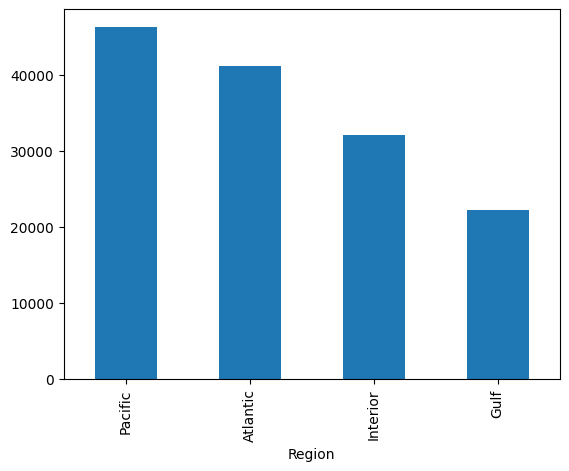

In [13]:
region_sales.plot(kind="bar")
plt.show()

In [14]:
state_orders = (df.groupby("State/Province")["Order ID"].count().sort_values(ascending=False))

In [15]:
state_orders.head(10)

State/Province
California        2001
New York          1128
Texas              985
Pennsylvania       587
Washington         506
Illinois           492
Ohio               469
Florida            383
Michigan           255
North Carolina     249
Name: Order ID, dtype: int64

In [16]:
ship_mode = (df.groupby("Ship Mode")["Lead Time"].mean())

NameError: name 'plot' is not defined

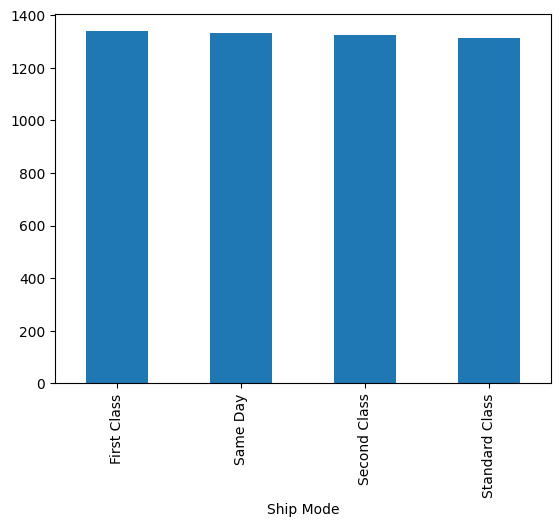

In [19]:
ship_mode.plot(kind="bar")
plot.show()

In [20]:
top_products = (df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False))

In [21]:
top_products.head(10)

Product Name
Wonka Bar - Triple Dazzle Caramel    28485.00
Wonka Bar -Scrumdiddlyumptious       27874.80
Wonka Bar - Milk Chocolate           26867.75
Wonka Bar - Fudge Mallows            24890.40
Wonka Bar - Nutty Crunch Surprise    23574.95
Lickable Wallpaper                    7860.00
Kazookles                             1205.75
Wonka Gum                              597.50
Everlasting Gobstopper                 130.00
Fizzy Lifting Drinks                    78.75
Name: Sales, dtype: float64

NameError: name 'plt' is not defined

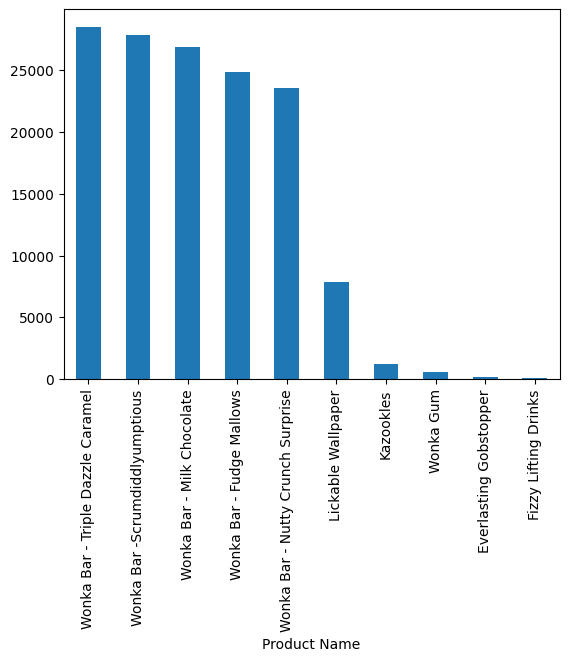

In [22]:
top_products.head(10).plot(kind="bar")
plt.show()

In [23]:
profit_products = (df.groupby("Product Name")["Gross Profit"].sum().sort_values(ascending=False))

In [24]:
df["Delayed"] = df["Lead Time"] > 7

In [25]:
delay_rate = (df["Delayed"].mean()*100)

In [26]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise":"Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":"Lot's O' Nuts",
    "Wonka Bar - Scrumdiddlyumptious":"Lot's O' Nuts",

    "Wonka Bar - Milk Chocolate":"Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":"Wicked Choccy's",

    "Laffy Taffy":"Sugar Shack",
    "SweeTARTS":"Sugar Shack",
    "Nerds":"Sugar Shack",
    "Fun Dip":"Sugar Shack",

    "Everlasting Gobstopper":"Secret Factory",
    "Lickable Wallpaper":"Secret Factory",
    "Wonka Gum":"Secret Factory",

    "Hair Toffee":"The Other Factory",
    "Kazookles":"The Other Factory"
}

In [27]:
df["Factory"] = (df["Product Name"].map(factory_map))

In [28]:
df["Route"] = (df["Factory"] +" → " +df["State/Province"])

In [29]:
route_analysis = (df.groupby("Route")["Lead Time"].mean())

In [30]:
fast_routes = (route_analysis.sort_values().head(10))

In [31]:
slow_routes = (route_analysis.sort_values(ascending=False).head(10))

In [32]:
bottleneck = (df.groupby("State/Province").agg({"Lead Time":"mean", "Order ID":"count"}))

In [33]:
df["Efficiency Score"] = (100 -(df["Lead Time"]/df["Lead Time"].max())*100)